# Quantify **Organelle Interactions** - part 2.2
--------------------
## **OBJECTIVE**
### <input type="checkbox"/> Quantify ***organelle interactions***
In this notebook, the logic for quantifying organelle **interaction composition** (how much of each interaction is present) and **morphology** (overlap site size and shape) is outlined.


---------
## **Organelle Interactions**

### summary of steps

🛠️ **BUILD FUNCTION PROTOTYPE**

- **`1`** - Examine how pair-wise overlappings are made

    - assemble list of pair-wise contacts

    - create overlapping regions between two organelle types

- **`2`** - Determine pair-wise overlappings that are present in triplet-wise overlaps (redundant overlaps)

    - iterate across all other organelle segmentations to find overlaps with the pair-wise overlapping region

    - watershed triplet-wise overlapping regions into pair-wise overlapping regions

- **`3`** - Use process for triplet-wise overlaps to make nth-wise overlaps 

    - assemble list of all possible contacts ranging from pair-wise to n-wise
    
    - iterate across n organelle types and create overlapping regions between them

- **`4`** - Expand on the method for finding redundant overlaps to find n-wise overlaps present in n+1 overlaps

    - iterate across all other organelle segmentations to find overlaps with the n-wise overlapping region

    - watershed n+1-wise overlaping regions into n-wise overlapping regions

- **`5`** - Build the list of measurements we want to include from regionprops and run regionprops

    - assemble list of measurements (morphological properties)

    - create initial regionprops table

- **`6`** - Track which individual organelles are involved in that interaction

    - identify labels involved in each unique interaction

    - correct and add measurements

⚙️ **EXECUTE FUNCTION PROTOTYPE**

- Define `_get_contact_metrics_3D` function
- Run `_get_contact_metrics_3D` function (scaled)
- Compare to finalized `get_contact_metrics_3D` function

## **IMPORTS**

#### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** This code block loads all of the necessary python packages and functions you will need for this notebook.

In [1]:
from pathlib import Path
import os

import napari
from napari.utils.notebook_display import nbscreenshot
from skimage.measure import (regionprops_table)
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from matplotlib.textpath import TextPath
import warnings
plt.rcParams['figure.dpi']= 300

from infer_subc.core.file_io import (read_czi_image,
                                     import_inferred_organelle,
                                     list_image_files)

from infer_subc.core.img import *
from infer_subc.utils.stats import *
from infer_subc.utils.stats import (_assert_uint16_labels)
from infer_subc.utils.stats_helpers import *
from infer_subc.utils.visualization import plot_overlaps, plot_n3_overlaps, plot_n_overlaps
from infer_subc.organelles import * 

##################
## Color Constants
##################
ORANGE = '#FFA500'
BOPBLUE = '#20ADF8'
MAROON = '#800000'
WHITE = '#FFFFFF'
BLACK = '#000000'

%load_ext autoreload
%autoreload 2

## **LOAD AND READ IN IMAGE FOR PROCESSING**
> ###### 📝 **Specifically, this will include the raw image and the outputs from segmentation**

#### &#x1F6D1; &#x270D; **User Input Required:**

In [2]:
## Define the path to the directory that contains the input image folder.
data_root_path = Path(os.path.expanduser("~")) / "Documents/Python Scripts/Infer-subc-2D/ncont vis/neuron"

## Specify which subfolder that contains the input data and what the file type is. Ex) ".czi" or ".tiff"
in_data_path = data_root_path / "raw"
raw_img_type = ".tiff"

## Specify which subfolder contains the segmentation outputs and their file type
seg_data_path = data_root_path / "seg"
seg_img_type = ".tiff"

## Specify the name of the output folder where quantification results will be saved
out_data_path = data_root_path / "quant"

## Specify which file you'd like to segment from the img_file_list
test_img_n = 0

## Specify the suffixes on the organelle segmentation files (i.e., the stuff following the "-")
org_names = ["lyso", "mito", "golgi", "perox", "ER", "LD"]

## Specify the suffixes on the region segmentation files (i.e., the stuff following the "-")
region_names = ["nuc", "cell"]

## Specify the organelles present in each channel of the raw image 
                ## syntax is {"organelle name": "channel number",...}
channel_orgs = {"lyso": 4,
                "mito": 3,
                "golgi": 2,
                "perox": 1,
                "ER": 0,
                "LD": 6,
                "nuc": 7,
                "PM": 5}

## Specify the suffix on the region segmentation file pertaining to the cell mask
mask = "cell"

## Specify the "splitter" that will be used between groupings of organelle names (i.e. lysoXmito)
splitter = "X"

#### &#x1F3C3; **Run code; no user input required**

In [3]:
if not Path.exists(out_data_path):
    Path.mkdir(out_data_path)
    print(f"making {out_data_path}")

raw_file_list = list_image_files(in_data_path, raw_img_type)
seg_file_list = list_image_files(seg_data_path, seg_img_type)
# pd.set_option('display.max_colwidth', None)
# pd.DataFrame({"Image Name":img_file_list})

In [4]:
raw_img_name = raw_file_list[test_img_n]

raw_img_data, raw_meta_dict = read_czi_image(raw_img_name)

channel_names = raw_meta_dict['name']
img = raw_meta_dict['metadata']['aicsimage']
scale = raw_meta_dict['scale']
channel_axis = raw_meta_dict['channel_axis']

In [5]:
org_segs = [import_inferred_organelle(org, raw_meta_dict, seg_data_path, seg_img_type) for org in org_names]
region_segs = [import_inferred_organelle(reg, raw_meta_dict, seg_data_path, seg_img_type) for reg in region_names]

loaded  inferred 3D `lyso`  from C:\Users\zscoman\Documents\Python Scripts\Infer-subc-2D\ncont vis\neuron\seg 
loaded  inferred 3D `mito`  from C:\Users\zscoman\Documents\Python Scripts\Infer-subc-2D\ncont vis\neuron\seg 
loaded  inferred 3D `golgi`  from C:\Users\zscoman\Documents\Python Scripts\Infer-subc-2D\ncont vis\neuron\seg 
loaded  inferred 3D `perox`  from C:\Users\zscoman\Documents\Python Scripts\Infer-subc-2D\ncont vis\neuron\seg 
loaded  inferred 3D `ER`  from C:\Users\zscoman\Documents\Python Scripts\Infer-subc-2D\ncont vis\neuron\seg 
loaded  inferred 3D `LD`  from C:\Users\zscoman\Documents\Python Scripts\Infer-subc-2D\ncont vis\neuron\seg 
loaded  inferred 3D `nuc`  from C:\Users\zscoman\Documents\Python Scripts\Infer-subc-2D\ncont vis\neuron\seg 
loaded  inferred 3D `cell`  from C:\Users\zscoman\Documents\Python Scripts\Infer-subc-2D\ncont vis\neuron\seg 


In [6]:
mask_img = region_segs[region_names.index("cell")]

In [7]:
organelle_segs = {}                                                     
for idx, name in enumerate(org_names):                                  
    if name == 'ER':                                                    
        organelle_segs[name]=apply_mask((org_segs[idx]>0).astype(np.uint16), mask_img)    
    else:                                                       
        organelle_segs[name]=org_segs[idx]                      

-----------------
Here we are defining an **organelle interaction** as any amount of pixel/voxel overlap between two organelles of different types. The overlap region will be know as the **interaction site**. We have implemented a pipeline that identifies two-way, three-way, and higher order contacts as well. This pipeline additionally distinguishes whether a contact is present in a higher order contact or not. Finally, the method for identifying individual contacts in this pipeline enables the use of "declumped" organelle segmentations.

We will utilize similar regionprops measurements as was done to quantify organelle and cell regions morphology.

> ###### 📝 **Since organelle contact sites are smaller than our resolution limit for confocal microscopy, the region of overlap is only an estimation of contacts. It may be helpful to dilate a single organelle (the organelle of interest) before determining the overlap region. This will include any touching, but not overlapping interactions and may improve our ability to detect differences in this subresolution system**

10-Sep-25 10:40:07 - vispy    - WARNING  - QWindowsWindow::setGeometry: Unable to set geometry 1600x1600+12+46 (frame: 1622x1656+1+1) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY1". Resulting geometry: 1600x1050+12+46 (frame: 1622x1106+1+1) margins: 11, 45, 11, 11 minimum size: 385x491 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=792,1038 maxtrack=0,0)
c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napar

RuntimeError: sequence argument must have length equal to input rank

c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


RuntimeError: sequence argument must have length equal to input rank

c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


RuntimeError: sequence argument must have length equal to input rank

c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


RuntimeError: sequence argument must have length equal to input rank

c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


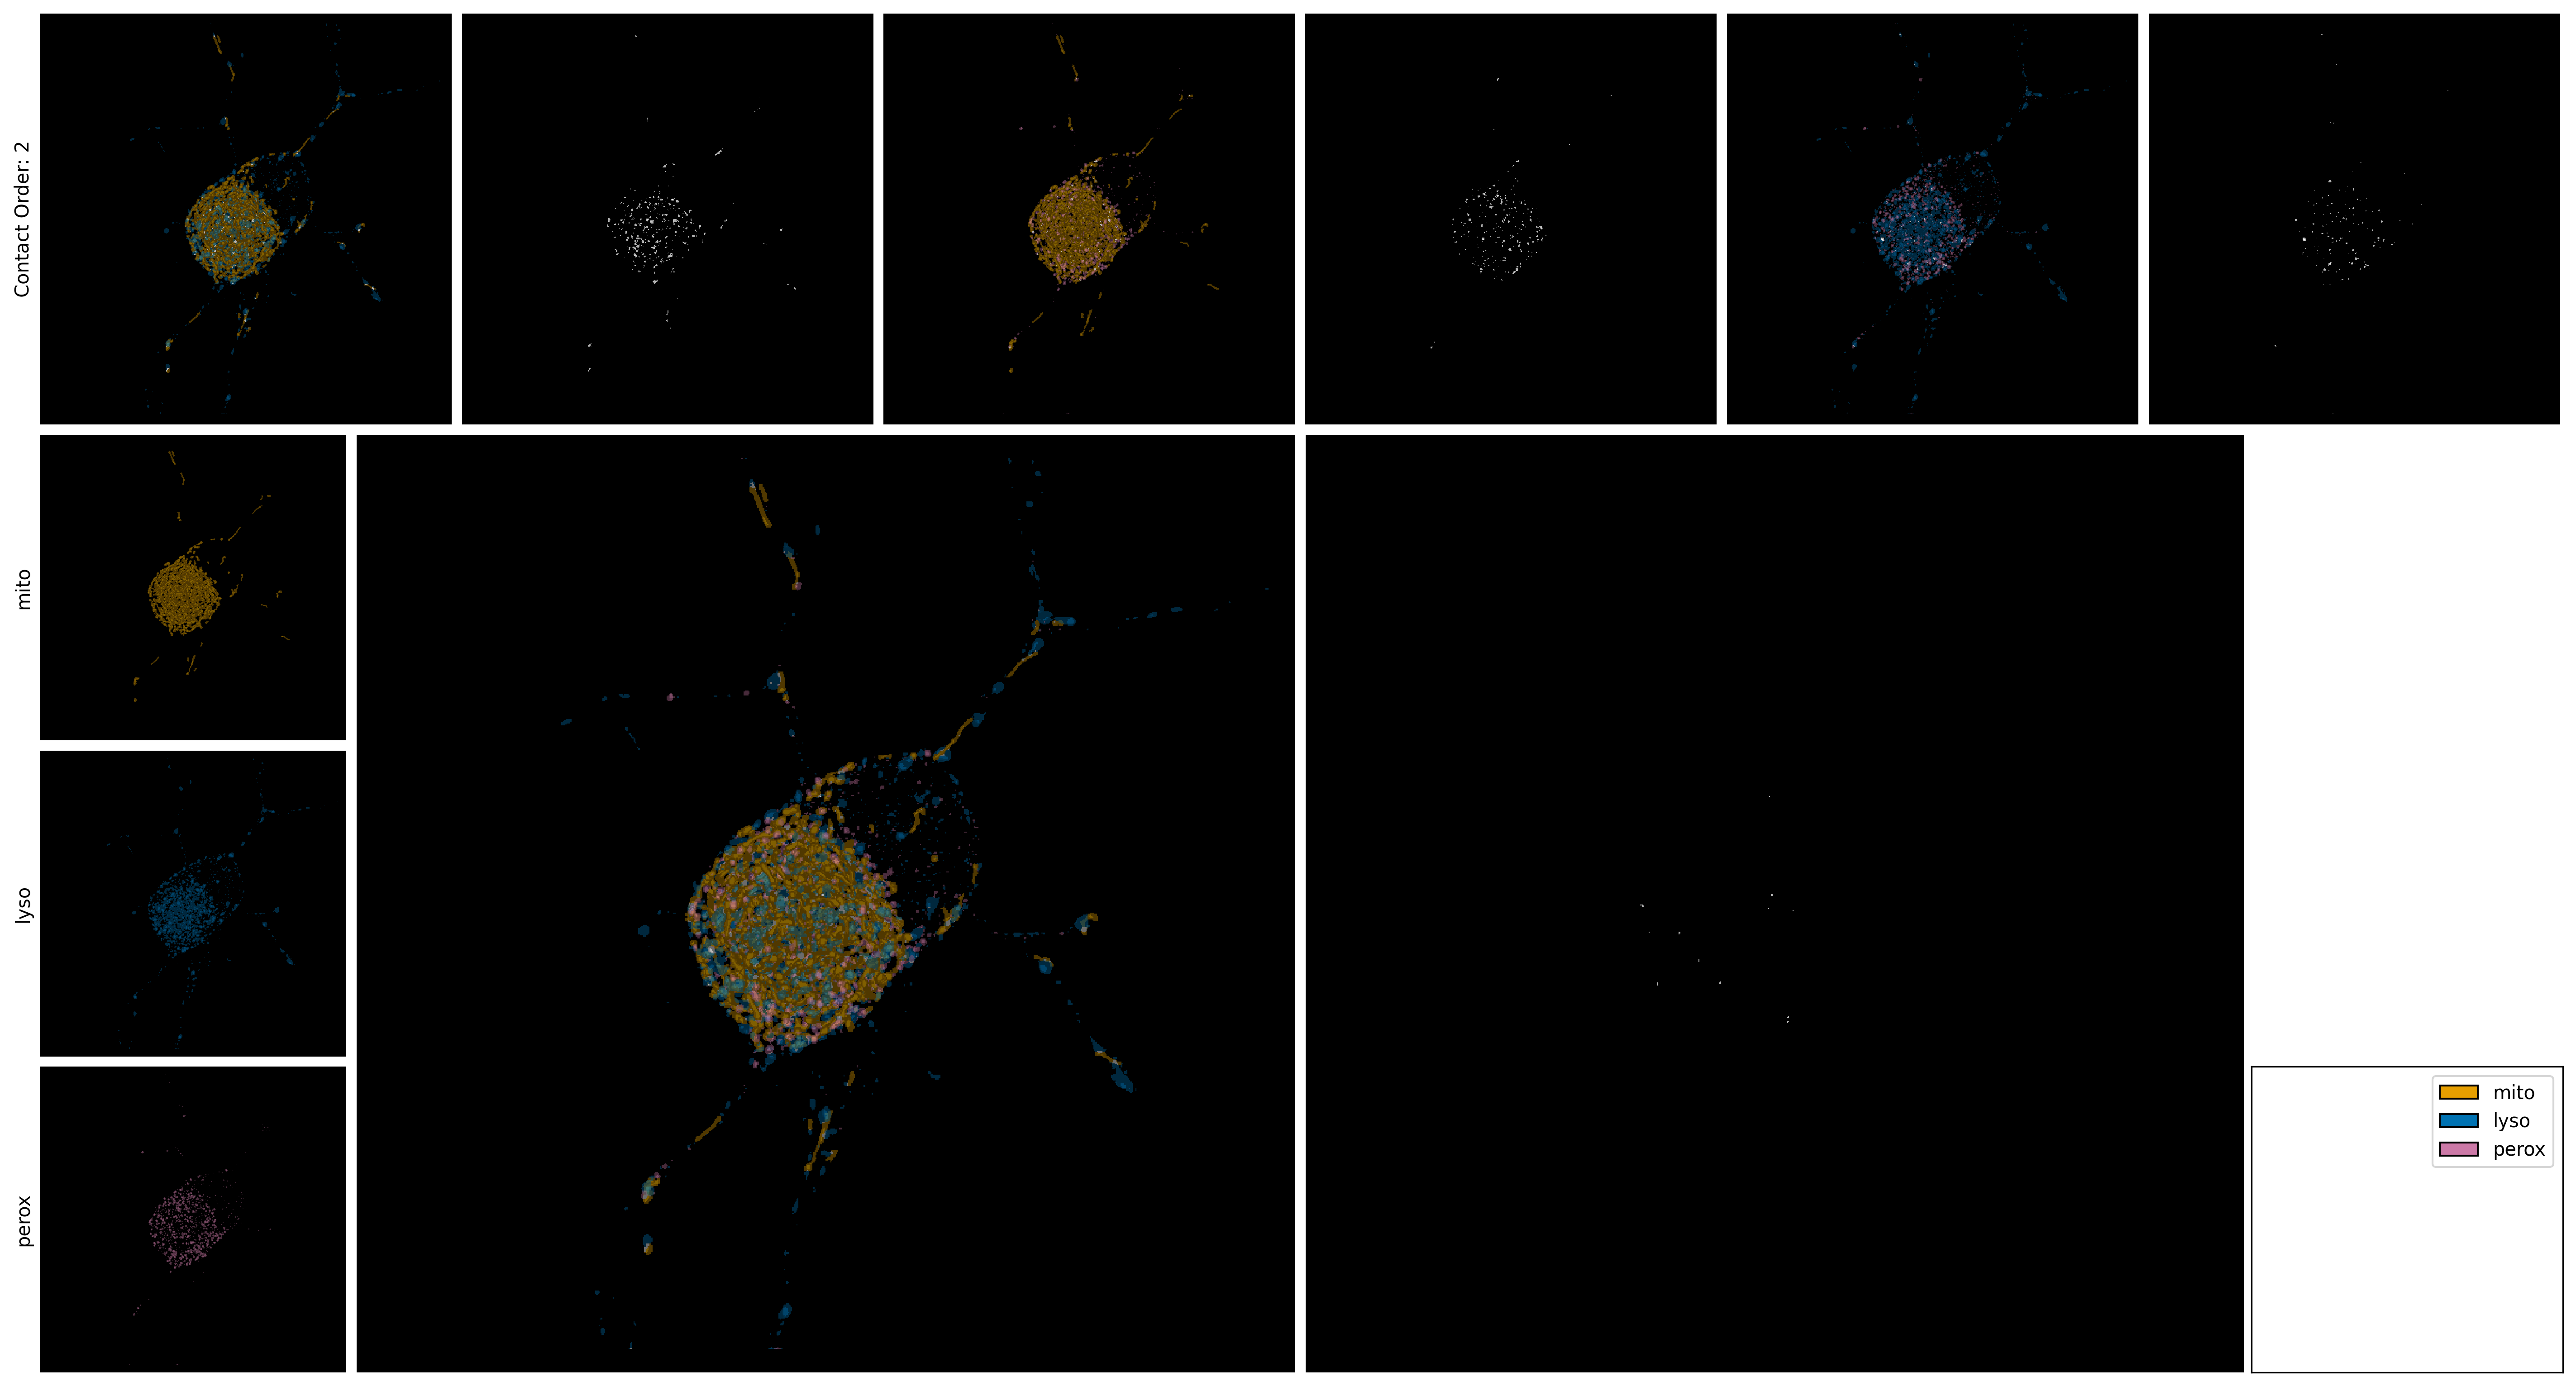

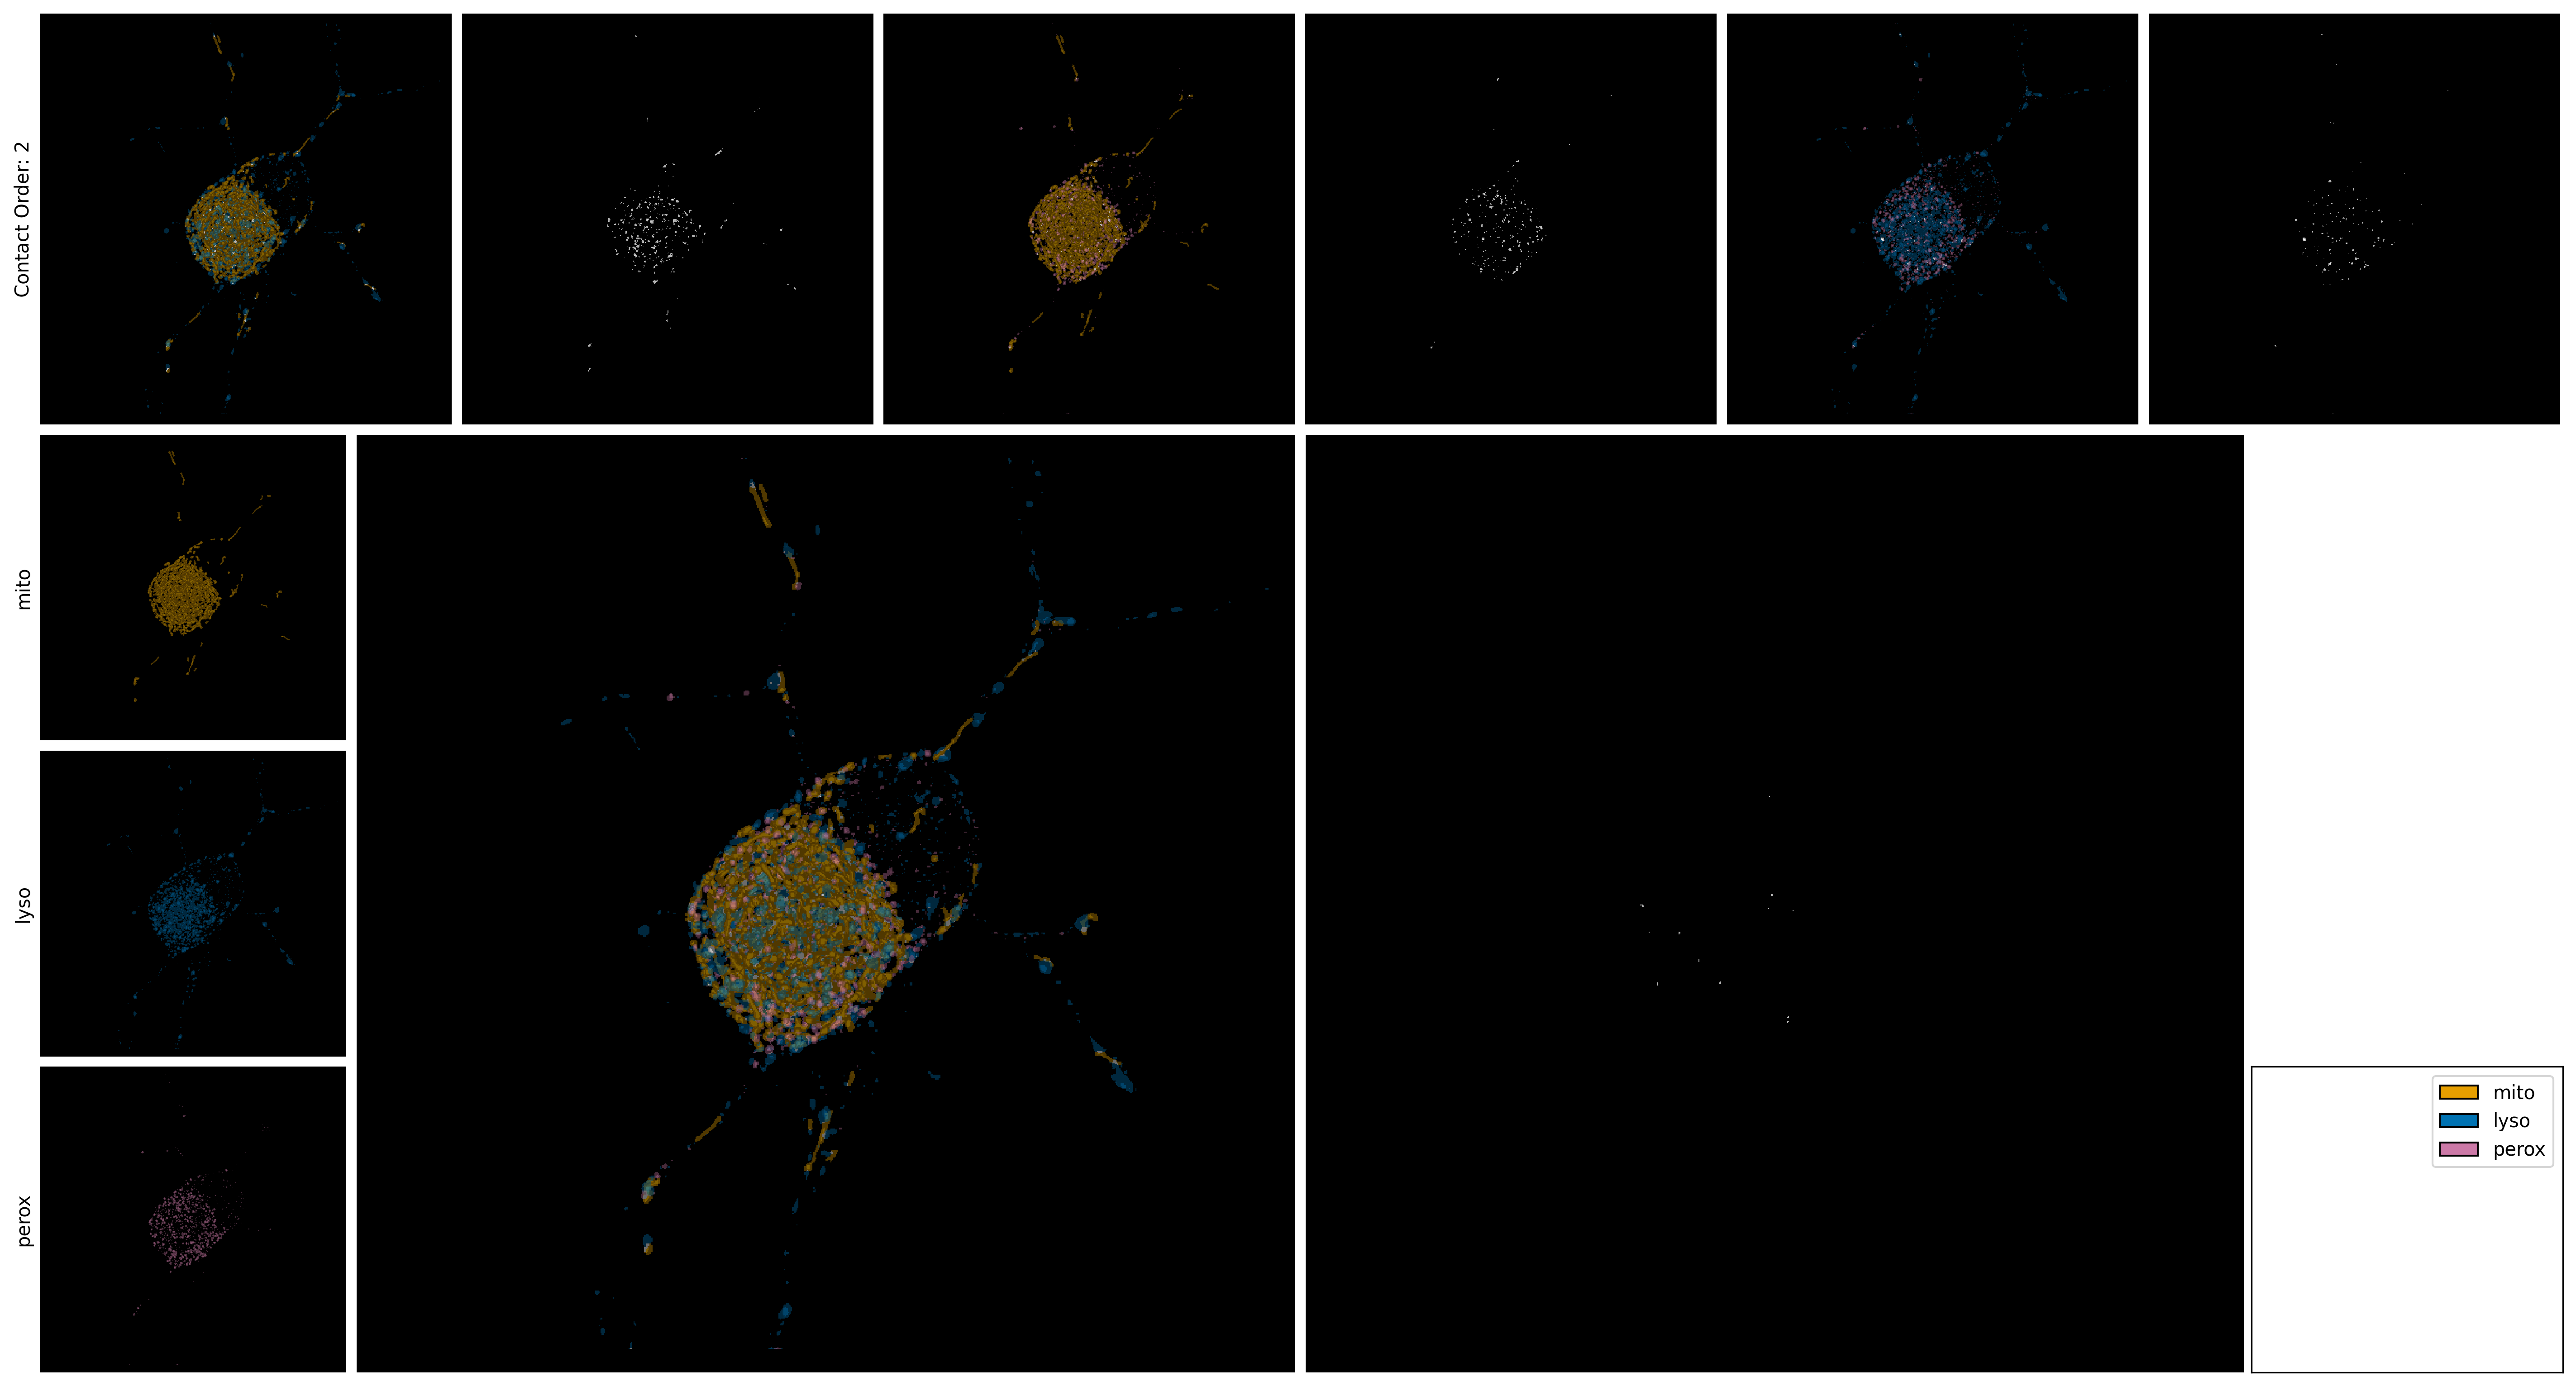

In [9]:
plot_n_overlaps('mitoXlysoXperox', 'X', organelle_segs, scale, close_viewer=True, view='3D')

# ***BUILD FUNCTION PROTOTYPE***

## **`1` - Examine how 2-Way overlappings are made**

**aXb**: organelle a overlapping with organelle b (*NOTE: aXb and bXa overlaps are redundant*)

- assemble list of pair-wise contacts

In [ ]:
paircomb = itertools.combinations(org_names, 2)
pairs = [splitter.join(inter) for inter in paircomb]
print(enumerate(pairs))

#### &#x1F6D1; &#x270D; **User Input Required:**

In [ ]:
# Enter the organelles in the desired pair
orgA = "mito"
orgB = "ER"

#### &#x1F3C3; **Run code; no user input required**

- create overlapping regions between two organelle types

In [ ]:
# Creating desired overlap regions
a = organelle_segs[orgA]        #collects organelle a
b = organelle_segs[orgB]        #collects organelle b
c = (a>0)*(b>0)                 #determines true overlapping area without labels
digit = len(str(np.max(a)))     #finds number of digits in largest valued label of organelle a segmentation
overlap = (b*(10**(digit+1)))+a #assigns unique labels to each overlap
overlap[c==False] = 0           #ensures that locations with no overlap are labeled as 0
overlap = label(overlap)        #simplifies labels

- visualize segmentations 'a' and 'b'

In [ ]:
plot_overlaps(orgs=(orgA+splitter+orgB), splitter=splitter, organelle_segs=organelle_segs, scale=scale, close=False, holo=False)

## **`3` - Generate nth order overlaps based off of higher order overlap function**

- assemble list of possible contacts

be clear that the method above can be used for more than 2 orgs if desired

In [ ]:
all_pos =[]
for n in list(map(lambda x:x+2, (range(len(org_names)-1)))):
    all_pos += itertools.combinations(org_names, n)
possib = [splitter.join(inter) for inter in all_pos]

print(list(enumerate(possib)))

#### &#x1F6D1; &#x270D; **User Input Required:**



In [ ]:
#Enter desired interaction's number (as shown in the above output)
number = 28

#### &#x1F3C3; **Run code; no user input required**
- iterate across n organelles and isolate the overlapping between all of them

In [ ]:
orgs = possib[number]
site = np.ones_like(organelle_segs[orgs.split(splitter)[0]])
for org in orgs.split(splitter):        #iterates across organelles within the interaction
    b = organelle_segs[org]             #selects for iterated organelle
    valid = (b>0)*(site>0)              #isolates to only the locations where there are overlaps
    digit = len(str(np.max(site)))      #finds number of digits in largest valued label of organelle a segmentation
    site = (b*(10**(digit)))+site       #assigns unique labels to each overlap
    site[valid.astype(bool)==False]=0   #ensures that locations with no overlap are labeled as 0
    site = label(site)                  #simplifies labels

- create the function

In [ ]:
def _create_overlap(orgs:str,
                    organelle_segs: dict[str:np.ndarray],
                    splitter: str="X") -> tuple[np.ndarray, np.ndarray]: 
    ##########################################
    ## CREATE OVERLAP
    ##########################################
    site = np.ones_like(organelle_segs[orgs.split(splitter)[0]])
    for org in orgs.split(splitter):
        b = organelle_segs[org]             
        valid = (b>0)*(site>0)
        digit = len(str(np.max(site)))      
        site = (b*(10**(digit)))+site       
        site[valid.astype(bool)==False]=0   
        site = label(site)             
    return site

- visualize segmentations 'a', 'b', and 'c' with the interactions between all 3 organelles visualized in white

# make clear that you are specifically talking about type of contact and num of orgs involved correctly!!!

In [ ]:
plot_overlaps(orgs=(orgs), splitter=splitter, organelle_segs=organelle_segs, scale=scale, close=True, holo=False)

## **`4` - Determine which nth order interactions are present in n+1 order interactions**

- adjust previous method for finding higher order contacts to work with nth order

In [ ]:
LOc_NR = site.copy()                         
for org, val in organelle_segs.items():         
    if (org not in orgs.split(splitter)         #Proceeds if the organelle is not any of the orgs in nth order
        and np.any(overlap*val)):               
        digit = len(str(np.max(val)))           
        valid = (LOc_NR>0)*(val>0)              
        HOc = (LOc_NR*(10**(digit)))+val        
        HOc[valid.astype(bool)==False]=0        
        HOc = label(HOc)                        
        for id in np.unique(site[HOc > 0]):   
            LOc_NR[LOc_NR==id] = 0              

- create the function

In [ ]:
def _find_non_redundant_overlaps(site: np.ndarray,
                                 orgs: str,
                                 organelle_segs: dict[str:np.ndarray],
                                 splitter: str="X"):
    ##########################################
    ## DETERMINE REDUNDANT OVERLAPS
    ##########################################
    LOc_NR = site.copy()                         
    for org, val in organelle_segs.items():         
        if (org not in orgs.split(splitter)
            and np.any(site*val)):
            print(f"Examining {orgs} Higher Order Interactions With {org}...", end="\r")               
            digit = len(str(np.max(val)))           
            valid = (LOc_NR>0)*(val>0)              
            HOc = (LOc_NR*(10**(digit)))+val        
            HOc[valid.astype(bool)==False]=0        
            HOc = label(HOc) 
            maxi = len(np.unique(LOc_NR[HOc>0]))                       
            for num, id in enumerate(np.unique(site[HOc > 0])):
                per = round((100*((num+1)/maxi)), 2)   
                LOc_NR[LOc_NR==id] = 0
                print(f"Examining {orgs} Higher Order Interactions With {org}: {per}% complete", end="\r")
            print(f"Examining {orgs} Higher Order Interactionss With {org}: {per}% complete")     
    return LOc_NR

- visualize segmentations 'a', 'b', and 'c', their interactions, and their interactions not present in higher order interactions

# maroon = higher or lower order overlap
# white = total overlapping region

In [ ]:
plot_overlaps(orgs=orgs, splitter=splitter, organelle_segs=organelle_segs, scale=scale)

In [ ]:
site = label(apply_mask(site, mask_img)).astype(int)

## **`5` - Build the list of measurements we want to include from regionprops and run regionprops**

- assemble list of measurements (morphological properties)

In [ ]:
# start with LABEL
test_Xproperties = ["label"]

# add position
test_Xproperties = test_Xproperties + ["centroid", "bbox"]

# add area
test_Xproperties = test_Xproperties + ["area", "equivalent_diameter"] # "num_pixels", 

# add shape measurements - NOTE: can't include minor axis measure because some of the interaction sites are only one pixel
test_Xproperties = test_Xproperties + ["extent", "euler_number", "solidity", "axis_major_length", "slice"] # "feret_diameter_max",  , "axis_minor_length"

- create initial regionprops table

In [ ]:
## NOTE: it may be worth our time to deal with the measurements that having issues with one voxel objects: 
## axis_min_length - the minimum axis of a voxel should be calulated as the minimum axis of a elipsoid with the same central moment as the voxel;
## when scaling this number should be calculated, but without scale, I think this would just be ~1

test_Xprops = regionprops_table(site, 
                                intensity_image=None, 
                                properties=test_Xproperties, 
                                extra_properties=None, 
                                spacing=scale)

In [ ]:
test_Xsurface_area_tab = pd.DataFrame(surface_area_from_props(site, test_Xprops, scale=scale))

## **`3` - Track which individual organelles are involved in that interaction**

- identify labels involved in each unique interaction

In [ ]:
inter_inv = []
involved = orgs.split(splitter)
indexes = dict.fromkeys(involved, [])
indexes[orgs] = []
for index, l in enumerate(test_Xprops["label"]):
    inter_inv.clear()
    for org in involved:
        volume = site[test_Xprops["slice"][index]]
        lorg = organelle_segs[org][test_Xprops["slice"][index]]
        volume = volume==l
        lorg = lorg[volume]                                 
        all_inv = np.unique(lorg[lorg>0]).tolist()          
        if len(all_inv) != 1:
            print(f"we have an error.  as-> {all_inv}")
        indexes[org].append(all_inv[0])
        inter_inv.append(f"{all_inv[0]}")
    indexes[orgs].append('_'.join(inter_inv))

- correct and add measurements

In [ ]:
props_table = pd.DataFrame(test_Xprops)
props_table.rename(columns={'label': 'idx'}, inplace=True)
props_table.drop(columns=['slice'], inplace=True)
props_table.insert(0, 'label',value=indexes[orgs])
props_table.insert(0, "object", orgs)
props_table.rename(columns={"area": "volume"}, inplace=True)
props_table.insert(11, "surface_area", test_Xsurface_area_tab)
props_table.insert(13, "SA_to_volume_ratio", 
props_table["surface_area"].div(props_table["volume"]))
if scale is not None:
    round_scale = (round(scale[0], 4), round(scale[1], 4), round(scale[2], 4))
    props_table.insert(loc=2, column="scale", value=f"{round_scale}")
else: 
    props_table.insert(loc=2, column="scale", value=f"{tuple(np.ones(site.ndim))}")

In [ ]:
props_table.head()

In [ ]:
LOc_NR = apply_mask((LOc_NR>0), mask_img).astype(int) * site
redundancy = props_table['idx'].isin(np.unique(LOc_NR[LOc_NR>0]).tolist())
fin_props_table = props_table.copy()
fin_props_table.insert(2, "in_higher_order", list(map(bool, ~redundancy)))
fin_props_table.drop(columns=['idx'], inplace=True)

In [ ]:
fin_props_table.head()

<!-- #### `WIP`: Adding a "SHELL" measurement for each site of interaction, we want to measure the membrane surface area from each organelle involved in the interaction

I think the most logical way to do this seems to be using marching_cubes to create an isosurface of each object (org A, org B, and the intersection), then cut the orgs' isosurface using the overlap region. The isosurface region of intersection between the org and the overlap will be measured as the membrane in the interaction.

- **shell_aXb**: the "shell", or membrane, of organelle a overlapping with organelle b (*NOTE: shell_aXb and shellbXa are *NOT* redundant*) -->

# ***EXECUTE FUNCTION PROTOTYPE***

## **Define `_make_dict` function**

In [ ]:
def _make_dict(list_obj_names: list[str],
               list_obj_segs: list[np.ndarray]):
    organelle_segs = {}                                                     
    for idx, name in enumerate(list_obj_names):                                  
        if name == 'ER':                                                    
            organelle_segs[name]=(list_obj_segs[idx]>0).astype(np.uint16)        
        else:                                                       
            organelle_segs[name]=list_obj_segs[idx]
    return organelle_segs

## **Define `_all_combo` function**

In [ ]:
def _all_combo(list_obj_names: list[str], splitter: str="X"):
    all_pos = []
    for n in list(map(lambda x:x+2, (range(len(list_obj_names)-1)))):
        all_pos += itertools.combinations(list_obj_names, n)
    possib = [splitter.join(inter) for inter in all_pos]
    return possib

## **Define `_create_contact` function**

In [ ]:
def _create_overlap(orgs:str,
                    organelle_segs: dict[str:np.ndarray],
                    splitter: str="X") -> tuple[np.ndarray, np.ndarray]: 
    ##########################################
    ## CREATE OVERLAP
    ##########################################
    site = np.ones_like(organelle_segs[orgs.split(splitter)[0]])
    for org in orgs.split(splitter):
        b = organelle_segs[org]             
        valid = (b>0)*(site>0)
        digit = len(str(np.max(site)))      
        site = (b*(10**(digit)))+site       
        site[valid.astype(bool)==False]=0   
        site = label(site)             
    return site

## **Define `_find_non_redundant_contacts` function**

In [ ]:
def _find_non_redundant_overlaps(site: np.ndarray,
                                 orgs: str,
                                 organelle_segs: dict[str:np.ndarray],
                                 splitter: str="X"):
    ##########################################
    ## DETERMINE REDUNDANT OVERLAPS
    ##########################################
    LOc_NR = site.copy()                         
    for org, val in organelle_segs.items():         
        if (org not in orgs.split(splitter)
            and np.any(site*val)):
            print(f"Examining {orgs} Higher Order Interactions With {org}...", end="\r")               
            digit = len(str(np.max(val)))           
            valid = (LOc_NR>0)*(val>0)              
            HOc = (LOc_NR*(10**(digit)))+val        
            HOc[valid.astype(bool)==False]=0        
            HOc = label(HOc) 
            maxi = len(np.unique(LOc_NR[HOc>0]))                       
            for num, id in enumerate(np.unique(site[HOc > 0])):
                per = round((100*((num+1)/maxi)), 2)   
                LOc_NR[LOc_NR==id] = 0
                print(f"Examining {orgs} Higher Order Interactions With {org}: {per}% complete", end="\r")
            print(f"Examining {orgs} Higher Order Interactions With {org}: {per}% complete")     
    return LOc_NR

## **Define `_contact_metric_analysis` function**

In [ ]:
def _interaction_metric_analysis(overlap_ID: str,
                                 list_obj_names: list[str],
                                 list_obj_segs: list[np.ndarray],
                                 mask: np.ndarray,
                                 splitter: str="X",
                                 scale: Union[tuple, None]=None,
                                 include_dist:bool=False, 
                                 dist_centering_obj: Union[np.ndarray, None]=None,
                                 dist_num_bins: Union[int, None]=None,
                                 dist_zernike_degrees: Union[int, None]=None,
                                 dist_center_on: Union[bool, None]=None,
                                 dist_keep_center_as_bin: Union[bool, None]=None,
                                 return_site: bool=False):
    """
    collect volumentric measurements of intersection between n organelle types

    Parameters
    ------------
    overlap_ID: str
        a value used to describe the organelles present in the overlap that can be divided by the splitter value
    org_dict: dict
        a dictionary of all object segmentations assigned to keys with their objects
    mask: np.ndarray
        3D (ZYX) binary mask of the area to measure interactions from
    splitter: str
        a value used to separate the overlap_ID to determine objects present in overlap
    scale: tuple
        a value present in the metadata determining the scale of the (ZYX) axis
    include_dist:bool=False
        *optional*
        True = include the XY and Z distribution measurements of the interaction sites within the masked region 
        (utilizing the functions get_XY_distribution() and get_Z_distribution() from Infer-subc)
        False = do not include distirbution measurements
    dist_centering_obj: Union[np.ndarray, None]=None
        ONLY NEEDED IF include_dist=True; if None, the center of the mask will be used
        3D (ZYX) np.ndarray containing the object to use for centering the XY distribution mask
    dist_num_bins: Union[int, None]=None
        ONLY NEEDED IF include_dist=True; if None, the default is 5
    dist_zernike_degrees: Unions[int, None]=None,
        ONLY NEEDED IF include_dist=True; if None, the zernike share measurements will not be included in the distribution
        the number of zernike degrees to include for the zernike shape descriptors
    dist_center_on: Union[bool, None]=None
        ONLY NEEDED IF include_dist=True; if None, the default is False
        True = distribute the bins from the center of the centering object
        False = distribute the bins from the edge of the centering object
    dist_keep_center_as_bin: Union[bool, None]=None
        ONLY NEEDED IF include_dist=True; if None, the default is True
        True = include the centering object area when creating the bins
        False = do not include the centering object area when creating the bins


    Regionprops measurements:
    ------------------------
    ['label',
    'centroid',
    'bbox',
    'area',
    'equivalent_diameter',
    'extent',
    'feret_diameter_max',
    'euler_number',
    'convex_area',
    'solidity',
    'axis_major_length',
    'axis_minor_length']

    Additional measurements:
    ----------------------
    ['surface_area']

    
    Returns
    -------------
    pandas dataframe of containing regionprops measurements (columns) for each overlap region (rows)
    
    """
    #########################
    ## CREATE ORG_DICT
    #########################
    org_dict = _make_dict(list_obj_names, list_obj_segs)

    #########################
    ## CREATE OVERLAP REGIONS
    #########################
    # run create overlap function
    site = _create_overlap(overlap_ID, org_dict, splitter)

    #assert the nth order overlap to within the cellmask
    labels = label(apply_mask(site, mask)).astype(int)


    ##########################################
    ## CREATE LIST OF REGIONPROPS MEASUREMENTS
    ##########################################
    # start with LABEL
    properties = ["label"]

    # add position
    properties += ["centroid", "bbox"]

    # add area
    properties += ["area", "equivalent_diameter"] # "num_pixels", 

    # add shape measurements - NOTE: can't include minor axis measure because some of the contact sites are only one pixel
    properties += ["extent", "euler_number", "solidity", "axis_major_length", "slice"] # "feret_diameter_max",  , "axis_minor_length"
    

    ##################
    ## RUN REGIONPROPS
    ##################
    props = regionprops_table(labels, 
                              intensity_image=None, 
                              properties=properties, 
                              extra_properties=None, 
                              spacing=scale)

    ##################################################################
    ## RUN SURFACE AREA FUNCTION SEPARATELY AND APPEND THE PROPS_TABLE
    ##################################################################
    surface_area_tab = pd.DataFrame(surface_area_from_props(labels, props, scale))


    ########################################################
    ## LIST WHICH ORGANELLES ARE INVOLVED IN THE INTERACTION
    ########################################################
    inter_inv = []
    involved = overlap_ID.split(splitter)
    indexes = dict.fromkeys(involved, [])
    indexes[overlap_ID] = []

    for index, l in enumerate(props["label"]):
        inter_inv.clear()
        for org in involved:
            volume = labels[props["slice"][index]]
            lorg = org_dict[org][props["slice"][index]]
            volume = volume==l
            lorg = lorg[volume]                                 
            all_inv = np.unique(lorg[lorg>0]).tolist()          
            if len(all_inv) != 1:
                print(f"we have an error.  as-> {all_inv}")
            indexes[org].append(all_inv[0])
            inter_inv.append(f"{all_inv[0]}")
        indexes[overlap_ID].append('_'.join(inter_inv))

        
    ##################################################
    ## CREATE COMBINED DATAFRAME OF THE QUANTIFICATION
    ##################################################
    props_table = pd.DataFrame(props)
    props_table.rename(columns={'label': 'idx'}, inplace=True)
    props_table.drop(columns=['slice'], inplace=True)
    props_table.insert(0, 'label',value=indexes[overlap_ID])
    props_table.insert(0, "object", overlap_ID)
    props_table.rename(columns={"area": "volume"}, inplace=True)
    props_table.insert(11, "surface_area", surface_area_tab)
    props_table.insert(13, "SA_to_volume_ratio", 
    props_table["surface_area"].div(props_table["volume"]))
    if scale is not None:
        round_scale = (round(scale[0], 4), round(scale[1], 4), round(scale[2], 4))
        props_table.insert(loc=2, column="scale", value=f"{round_scale}")
    else: 
        props_table.insert(loc=2, column="scale", value=f"{tuple(np.ones(labels.ndim))}")


    ######################################################
    ## optional: DISTRIBUTION OF INTERACTION MEASUREMENTS
    ######################################################
    if include_dist:
        XY_interaction_dist, XY_bins, XY_wedges = get_XY_distribution(mask=mask, 
                                                                  obj=site,
                                                                  obj_name=overlap_ID,
                                                                  centering_obj=dist_centering_obj,
                                                                  scale=scale,
                                                                  center_on=dist_center_on,
                                                                  keep_center_as_bin=dist_keep_center_as_bin,
                                                                  num_bins=dist_num_bins,
                                                                  zernike_degrees=dist_zernike_degrees)
        
        Z_interaction_dist = get_Z_distribution(mask=mask,
                                            obj=site,
                                            obj_name=overlap_ID,
                                            center_obj=dist_centering_obj,
                                            scale=scale)
        interaction_dist_tab = pd.merge(XY_interaction_dist, Z_interaction_dist, on=["object", "scale"])

        indexes.clear()
        if return_site:
            return site, props_table, interaction_dist_tab
        else:
            return props_table, interaction_dist_tab
    else:
        indexes.clear()
        if return_site:
            return site, props_table
        else:
            return props_table

## **Define `_get_contact_metrics_3D` function**

Based on the _prototyping_ above define the function to quantify amount, size, and shape of organelles.

In [ ]:
def _get_interaction_metrics_3D(list_obj_names: list[str],
                                list_obj_segs: list[np.ndarray],
                                mask: np.ndarray,
                                splitter: str="X",
                                scale: Union[tuple, None]=None,
                                include_dist:bool=False, 
                                dist_centering_obj: Union[np.ndarray, None]=None,
                                dist_num_bins: Union[int, None]=None,
                                dist_zernike_degrees: Union[int, None]=None,
                                dist_center_on: Union[bool, None]=None,
                                dist_keep_center_as_bin: Union[bool, None]=None):
    """
    collect volumentric measurements of intersection between n, n+1, n+2... organelle types for an entire cell

    Parameters
    ------------
    list_obj_names: list
        a list of the names of objects used in making overlaps
    list_obj_segs: list
        a list of the segmentations of the objects used in making overlaps
    mask: np.ndarray
        3D (ZYX) binary mask of the area to measure overlaps from
    splitter: str="X"
        a value used to separate the organelles in their IDs
    scale: tuple
        3D (ZYX) assignment for the scaling of each axis
        include_dist:bool=False
        *optional*
        True = include the XY and Z distribution measurements of the interaction sites within the masked region 
        (utilizing the functions get_XY_distribution() and get_Z_distribution() from Infer-subc)
        False = do not include distirbution measurements
    dist_centering_obj: Union[np.ndarray, None]=None
        ONLY NEEDED IF include_dist=True; if None, the center of the mask will be used
        3D (ZYX) np.ndarray containing the object to use for centering the XY distribution mask
    dist_num_bins: Union[int, None]=None
        ONLY NEEDED IF include_dist=True; if None, the default is 5
    dist_zernike_degrees: Unions[int, None]=None,
        ONLY NEEDED IF include_dist=True; if None, the zernike share measurements will not be included in the distribution
        the number of zernike degrees to include for the zernike shape descriptors
    dist_center_on: Union[bool, None]=None
        ONLY NEEDED IF include_dist=True; if None, the default is False
        True = distribute the bins from the center of the centering object
        False = distribute the bins from the edge of the centering object
    dist_keep_center_as_bin: Union[bool, None]=None
        ONLY NEEDED IF include_dist=True; if None, the default is True
        True = include the centering object area when creating the bins
        False = do not include the centering object area when creating the bins

    Regionprops measurements:
    ------------------------
    ['label',
    'centroid',
    'bbox',
    'area',
    'equivalent_diameter',
    'extent',
    'feret_diameter_max',
    'euler_number',
    'convex_area',
    'solidity',
    'axis_major_length',
    'axis_minor_length']

    Additional measurements:
    ----------------------
    ['surface_area']

    
    Returns
    -------------
    pandas dataframe of containing regionprops measurements (columns) for each overlap region (rows)
    """

    ########################
    ## CREATE ORGANELLE DICT
    ########################
    organelle_segs = _make_dict(list_obj_names, list_obj_segs)                                                 
    
    #########################
    ## LIST POSSIBLE OVERLAPS
    #########################
    possib = _all_combo(list_obj_names, splitter)

    #######################
    ## ANALYZE ALL OVERLAPS
    #######################
    inter_tabs=[]
    dist_tabs=[]
    if include_dist:
        for inter in possib:
            inter_tab, dist_tab, site = _interaction_metric_analysis(overlap_ID=cont,
                                                                    list_obj_names=list_obj_names,
                                                                    list_obj_segs=list_obj_segs,
                                                                    org_dict=organelle_segs,
                                                                    mask=mask,
                                                                    splitter=splitter,
                                                                    scale=scale,
                                                                    include_dist=True,
                                                                    dist_centering_obj=dist_centering_obj,
                                                                    dist_num_bins=dist_num_bins,
                                                                    dist_zernike_degrees=dist_zernike_degrees,
                                                                    dist_center_on=dist_center_on,
                                                                    dist_keep_center_as_bin=dist_keep_center_as_bin,
                                                                    return_site=True)
            LOc_NR = _find_non_redundant_overlaps(site, inter, organelle_segs, splitter)
            LOc_NR = apply_mask((LOc_NR>0), mask).astype(int) * site
            redundancy = props_table['idx'].isin(np.unique(LOc_NR[LOc_NR>0]).tolist())
            inter_tab.insert(2, "in_higher_order", list(map(bool, ~redundancy)))
            inter_tab.drop(columns=['idx'], inplace=True)
            inter_tabs.append(inter_tab)
            dist_tabs.append(dist_tab)
        return inter_tabs, dist_tabs
    else:
        for inter in possib:
            inter_tab, site = _interaction_metric_analysis(overlap_ID=inter,
                                                          org_dict=organelle_segs,
                                                          mask=mask,
                                                          splitter=splitter,
                                                          scale=scale,
                                                          include_dist=False,
                                                          return_site=True)
            LOi_NR = _find_non_redundant_overlaps(site, inter, organelle_segs, splitter)
            LOi_NR = apply_mask((LOi_NR>0), mask).astype(int) * site
            redundancy = props_table['idx'].isin(np.unique(LOc_NR[LOc_NR>0]).tolist())
            inter_tab.insert(2, "in_higher_order", list(map(bool, ~redundancy)))
            inter_tab.drop(columns=['idx'], inplace=True)
            inter_tabs.append(inter_tab)
        return inter_tabs

## **Run `_get_contact_metrics_3D` function (scaled)**

In [ ]:
stat_tab_test, test_inter_dist_tab = _interaction_metric_analysis(overlap_ID=orgs,
                                                                 list_obj_names=org_names,
                                                                 list_obj_segs=org_segs,
                                                                 mask=region_segs[region_names.index("cell")], 
                                                                 scale=scale,
                                                                 include_dist=True, 
                                                                 dist_centering_obj=region_segs[region_names.index("nuc")],
                                                                 dist_center_on=False,
                                                                 dist_keep_center_as_bin=True,
                                                                 dist_num_bins=5,
                                                                 dist_zernike_degrees=9)

stat_tab_test.equals(props_table)

In [ ]:
test_inter_dist_tab

## **Compare to finalized `get_contact_metrics_3D` function**

In [ ]:
from infer_subc.utils.stats import interaction_metric_analysis

test_stat_tab_final, test_inter_dist_tab_final = interaction_metric_analysis(overlap_ID=orgs, 
                                                                            list_obj_names=org_names,
                                                                            list_obj_segs=org_segs,
                                                                            mask=region_segs[region_names.index("cell")], 
                                                                            scale=scale,
                                                                            include_dist=True, 
                                                                            dist_centering_obj=region_segs[region_names.index("nuc")],
                                                                            dist_center_on=False,
                                                                            dist_keep_center_as_bin=True,
                                                                            dist_num_bins=5,
                                                                            dist_zernike_degrees=9)

stat_tab_test.equals(test_stat_tab_final), test_inter_dist_tab.equals(test_inter_dist_tab_final)